### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Image Classification using baseline CNN and customized CNN architectures

### Contents
1. Section 1 : Loading Dataset
2. Section 2 : Exploratory Data Analysis
3. Section 3 : Baseline CNN Modelling on Original data
5. Section 4 : Data Augmentation
6. Section 5 : Baseline CNN Modelling on Augmented data

### File Outcome
*A set of processed grayscale images that are used for feature extraction and model training*

### Drive Mounting

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# !unzip ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/student_25675238.zip -d ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/

### System GPU Checks

In [1]:
#Check GPU
!nvidia-smi

Mon May 11 11:48:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.58.03              Driver Version: 595.58.03      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   34C    P0             31W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc


/opt/conda/nvvm/libdevice/libdevice.10.bc


### Library Imports

In [3]:
!pip install opencv-python --quiet

In [4]:
!pip install pydot

In [5]:
!pip install silence-tensorflow

In [6]:
# Importing required libraries and setting global variables
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pydot
import random
import tensorflow as tf
import keras

dataset_path = './25675238/Image_Classification/dataset'
data_files_path = './data_files/Image_Classification'
results_files_path = './results_and_models'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false'
os.environ['XLA_FLAGS'] = 'xla_gpu_autotune_level=0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

2026-05-11 11:48:35.007568: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 11:48:35.021793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778500115.040490    4904 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778500115.046901    4904 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778500115.061231    4904 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers
from keras import optimizers
from keras.applications import VGG16, ResNet50
from keras.applications.vgg16 import preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from silence_tensorflow import silence_tensorflow

tf.get_logger().setLevel('ERROR')
silence_tensorflow()

### Section 1 : Loading Dataset

In [ ]:
#Renaming folder names to lowercase # This operation is for one-time execution
# for folder in classes:
#     folder_path = os.path.join(dataset_path, folder)
#     new_path = os.path.join(dataset_path, folder.lower())
#     os.rename(folder_path, new_path)

In [8]:
classes = os.listdir(dataset_path)

In [8]:
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [9]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk -F'/' '{printf "%-30s : %s images\n", $NF, $1}'

bernese_mountain_dog           :     218 . images
borzoi                         :     151 . images
brittany_spaniel               :     152 . images
chihuahua                      :     152 . images
german_short-haired_pointer    :     152 . images
norwegian_elkhound             :     196 . images
schipperke                     :     154 . images
sussex_spaniel                 :     151 . images
toy_terrier                    :     172 . images
wire-haired_fox_terrier        :     157 . images


In [10]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 1655

### Section 2 : Exploratory Data Analysis

*In this section, we explore the characteristics of this dataset. We will use OpenCV library to access and examine the images*

*As shown in the previous sections, the dataset contains of 10 classes of dog images.*

*Each class consists of different number of images, bringing the total number of images to 1655.*

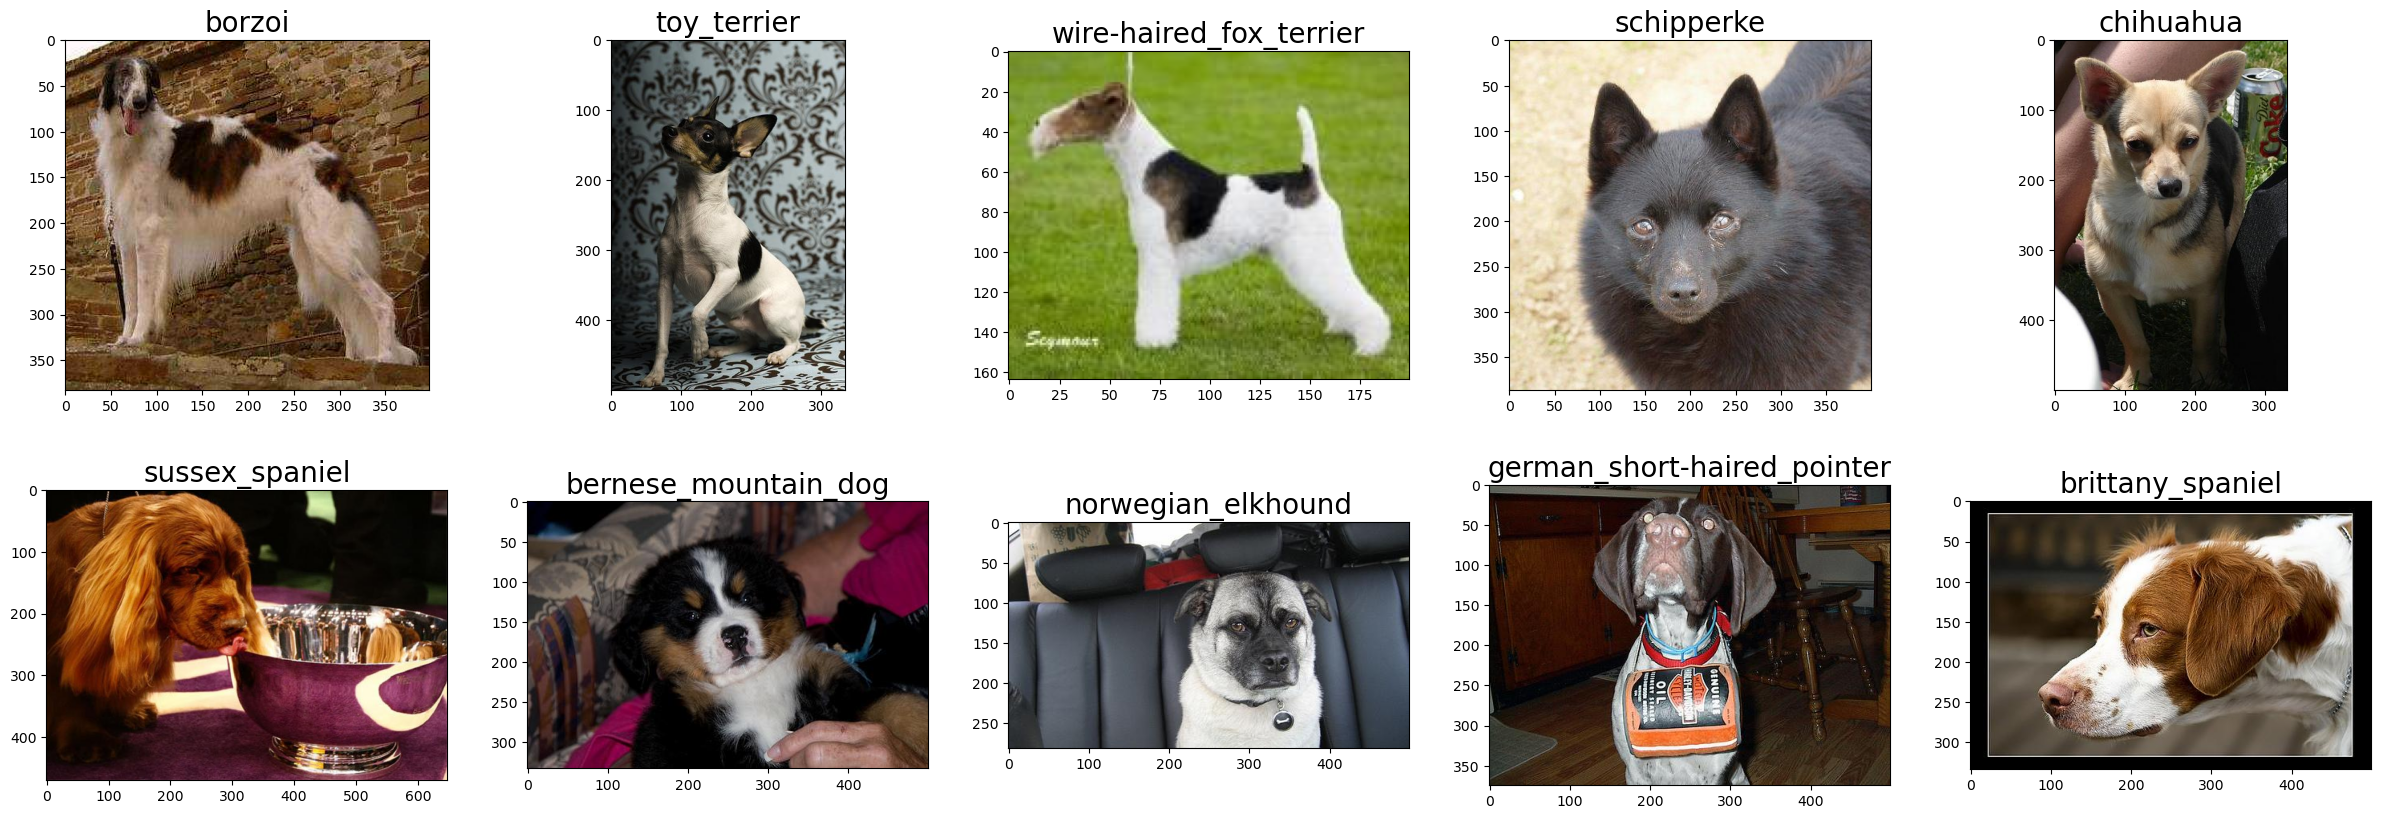

In [9]:
#Analysing images from every class

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30,10))
class_idx = 0
for i in range(2):
    for j in range(5):
        folder_path = dataset_path + "/" + classes[class_idx]
        images_path = os.listdir(folder_path)
        img_idx = random.randint(0, len(images_path) - 1) # Showing a random image for the same class on every run
        img = cv2.imread(folder_path + "/" + images_path[img_idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i,j].imshow(img)
        axes[i,j].set_title(classes[class_idx], fontsize=20)
        class_idx += 1
plt.show()

In [10]:
#Printing image shape
image = cv2.imread(dataset_path + '/bernese_mountain_dog/01.jpg')
print("Image dimensions :", image.shape)
print("Image data type :", image.dtype)
print("Image width :", image.shape[0])
print("Image length :", image.shape[1])

Image dimensions : (333, 500, 3)
Image data type : uint8
Image width : 333
Image length : 500


*It can be observed that the images have 3 (RGB) channels.*

All images analysed for class :  borzoi


All images analysed for class :  toy_terrier
All images analysed for class :  wire-haired_fox_terrier


All images analysed for class :  schipperke


All images analysed for class :  chihuahua


All images analysed for class :  sussex_spaniel


All images analysed for class :  bernese_mountain_dog


All images analysed for class :  norwegian_elkhound


All images analysed for class :  german_short-haired_pointer
All images analysed for class :  brittany_spaniel


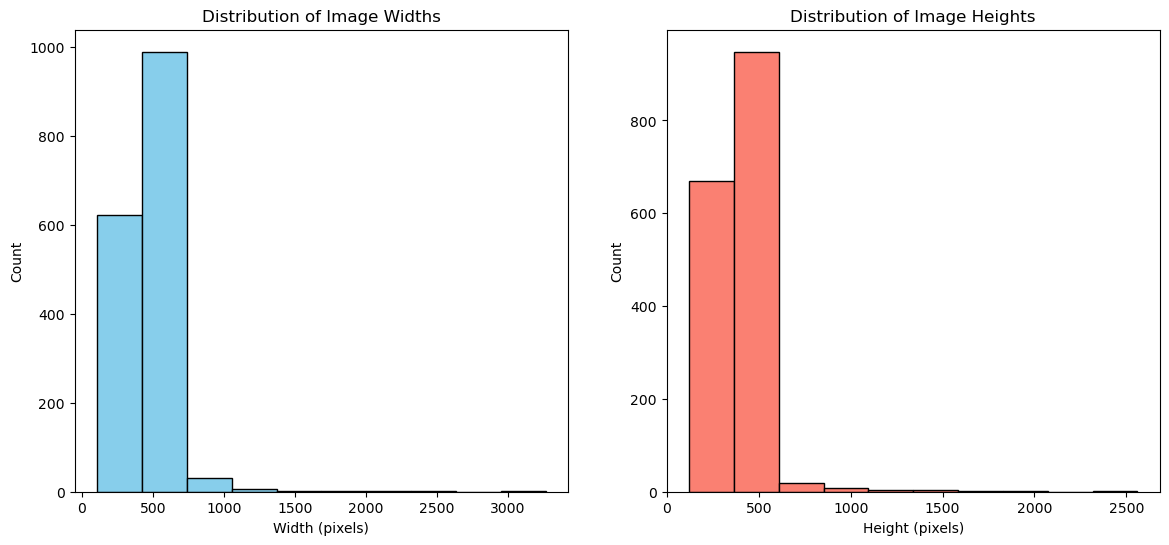

In [10]:
#Gathering image widths and heights and observing their distribution
widths = []
heights = []

#While traversing all images and labels, store them into separate arrays
#The images array will contain the image while the labels array will contain the class name as the label for that image
images = []
labels = []

for class_name in classes:
    folder_path = dataset_path + "/" + class_name
    images_path = os.listdir(folder_path)
    for i in images_path:
        img_path = folder_path + "/" + i
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

        images.append(img)
        labels.append(class_name)
    print("All images analysed for class : ", class_name)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Width Histogram
ax1.hist(widths, bins=10, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Image Widths')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Count')

# Height Histogram
ax2.hist(heights, bins=10, color='salmon', edgecolor='black')
ax2.set_title('Distribution of Image Heights')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Count')

plt.show()

*It can be observed that all images belonging to the 10 classes have varied heights and widths which requires further processing before ingesting them into the CNN model.*

*From the obove mentioned distribtion it can be seen that maximum images have heights and widths around 500px, which is a significantly larger image for CNN training*

In [13]:
#Writing the raw images and labels to .npy files for reuse
images_np_array = np.array(images, dtype=object)
labels_np_array = np.array(labels, dtype=object)

np.savez(data_files_path + '/original_images.npz', images_np_array)
np.savez(data_files_path + '/original_labels.npz', labels_np_array)

### Section 3 : Original data loading and Augmentation

In [14]:
# Loading the preprocessed images from npz files
with np.load(data_files_path + '/original_images.npz', allow_pickle=True) as data:
    images = list(data['arr_0'])

In [15]:
# Loading the original labels from the npz files
with np.load(data_files_path + '/original_labels.npz', allow_pickle=True) as data:
    labels = list(data['arr_0'])

In [16]:
# Encoding labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [17]:
# Creating training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, encoded_labels,
    test_size=0.15,
    train_size=0.85,
    random_state=25675238 #Using student ID as random seed
)

In [18]:
# Creating validation set
images_valid = images_train[:250]
labels_valid = labels_train[:250]

images_train = images_train[250:]
labels_train = labels_train[250:]

*The dataset is initially split into 85% training set and 15% testing set.*

*The training set is split into another 70% and 15% validation set*

In [19]:
# Image resizing
# The images of variable length are resized to 224x224 to standardize the input to the baseline models
resize_train_image = []
resize_valid_image = []
resize_test_image = []

for img in images_train:
    rsz_img = cv2.resize(img, (224, 224))
    resize_train_image.append(rsz_img)
for img in images_valid:
    rsz_img = cv2.resize(img, (224, 224))
    resize_valid_image.append(rsz_img)
for img in images_test:
    rsz_img = cv2.resize(img, (224, 224))
    resize_test_image.append(rsz_img)

In [20]:
# Converting list of images to numpy array for model training
images_train = np.asarray(resize_train_image).astype('float32')
images_valid = np.asarray(resize_valid_image).astype('float32')
images_test = np.asarray(resize_test_image).astype('float32')

In [21]:
labels_train = np.asarray(labels_train)
labels_valid = np.asarray(labels_valid)
labels_test = np.asarray(labels_test)

In [22]:
classes = os.listdir(dataset_path)
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [23]:
# Creating augmentation samples for visualization
augmented_samples_path = './augmented_samples'

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for name in classes:
    i = 0
    for batch in datagen.flow(
        images_train,
        labels_train,
        batch_size=1,
        save_to_dir=augmented_samples_path, 
        save_prefix=f'aug_{name}', 
        save_format='jpeg'
    ):
        i += 1
        if i >= 2:
            break 
    print(f"Created 2 samples for {name}")

# Cleanup augmented samples
!rm -r ./augmented_samples/.ipynb_checkpoints

Created 2 samples for borzoi
Created 2 samples for toy_terrier
Created 2 samples for wire-haired_fox_terrier
Created 2 samples for schipperke
Created 2 samples for chihuahua
Created 2 samples for sussex_spaniel
Created 2 samples for bernese_mountain_dog
Created 2 samples for norwegian_elkhound
Created 2 samples for german_short-haired_pointer
Created 2 samples for brittany_spaniel


rm: cannot remove './augmented_samples/.ipynb_checkpoints': No such file or directory


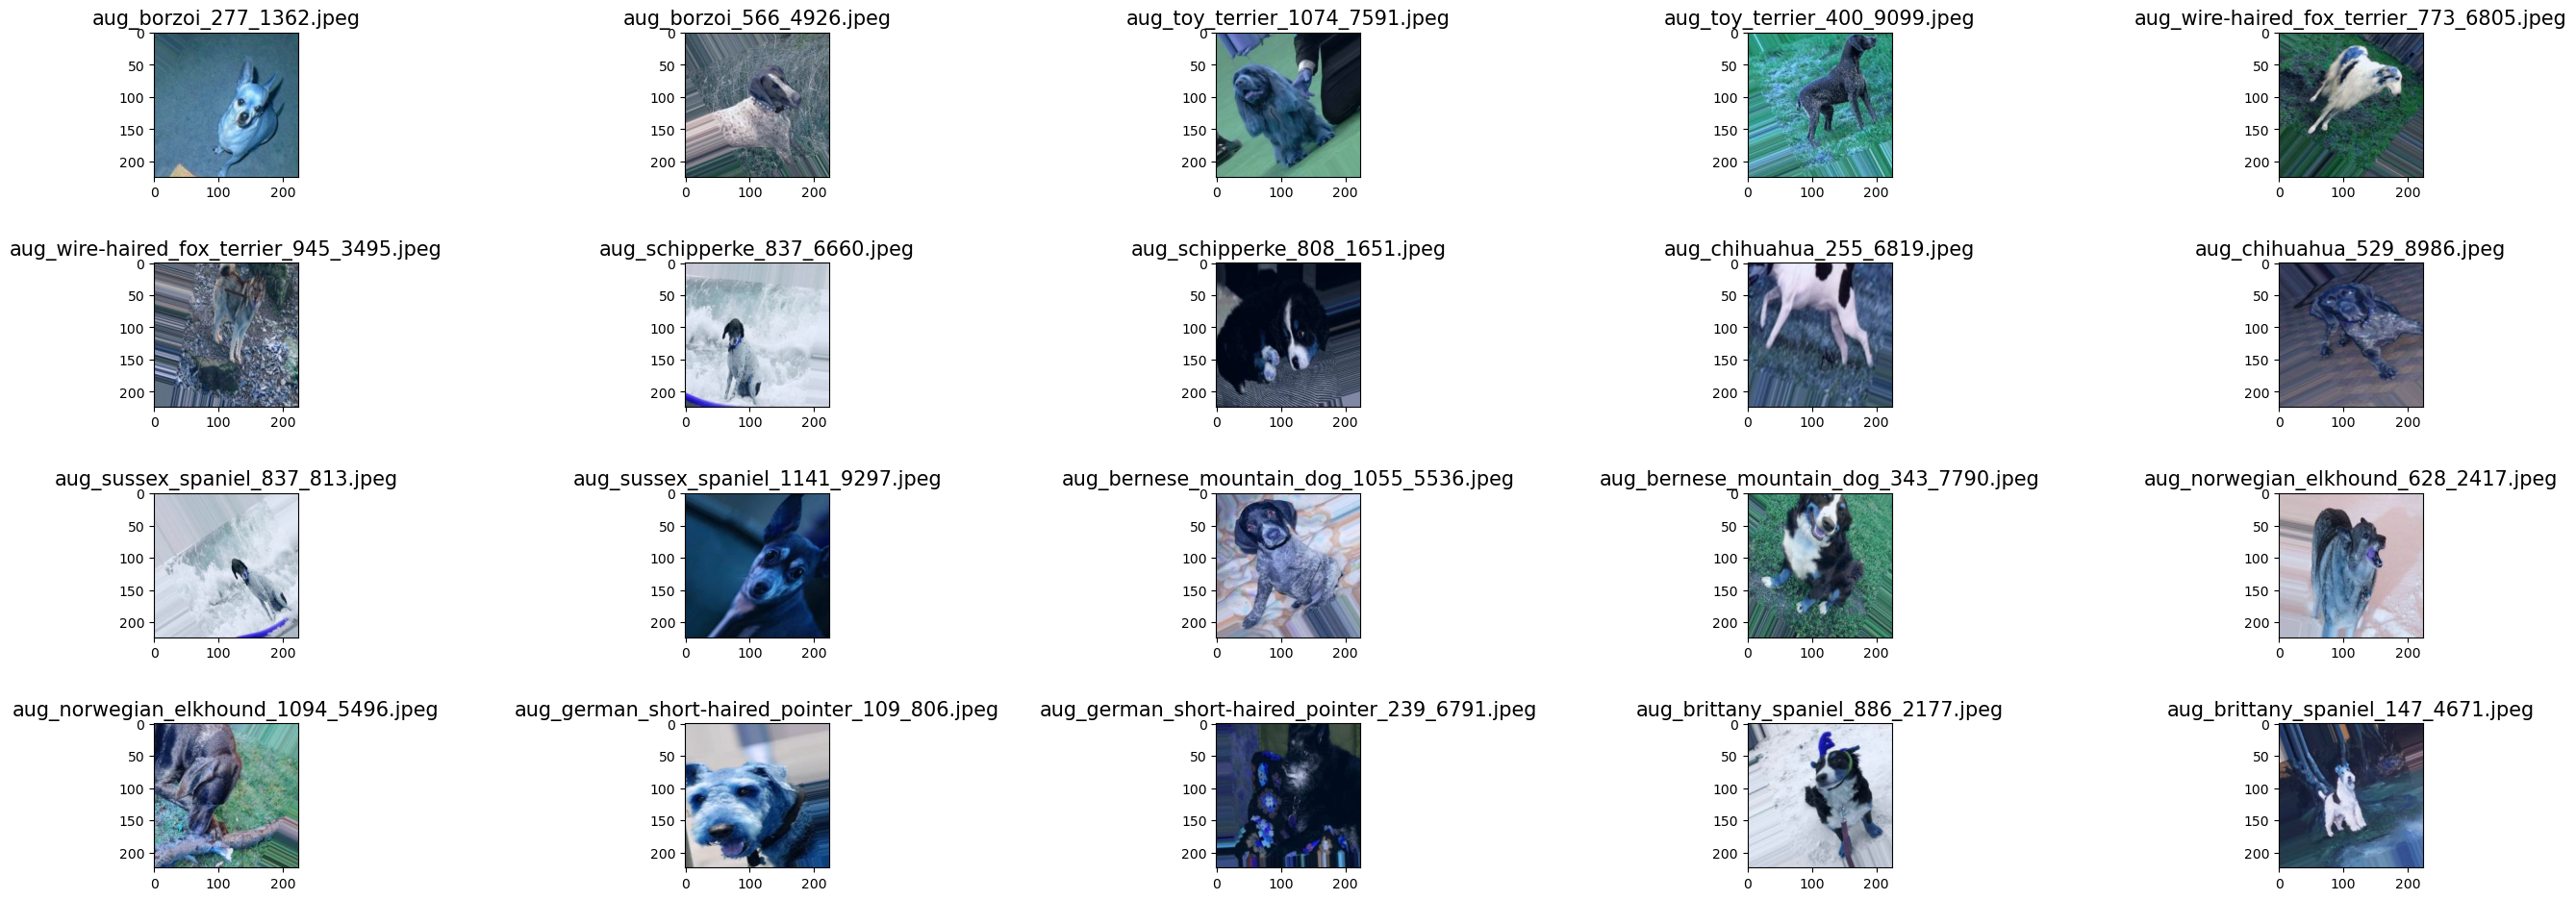

In [24]:
# Analysing augmented images from every class

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(30,10))
augmented_images = os.listdir(augmented_samples_path)
aug_img_idx = 0
for i in range(4):
    for j in range(5):
        img = cv2.imread(augmented_samples_path + "/" + augmented_images[aug_img_idx])
        axes[i,j].imshow(img)
        axes[i,j].set_title(augmented_images[aug_img_idx], fontsize=15)
        aug_img_idx += 1
plt.tight_layout(pad=3.0)
plt.show()

In [25]:
# Cleanup augmented samples
!rm -rf ./augmented_samples/*

In [26]:
train_datagen = ImageDataGenerator(
      preprocessing_function=preprocess_input,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow(
        images_train,
        labels_train,
        batch_size=36,
        seed=25675238
        )

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow(
        images_valid,
        labels_valid,
        batch_size=36,
        seed=25675238
        )

### Section 3 : Baseline CNN Modelling (VGG16) on Original Data

In [27]:
# Using VGG16 model with pretrained weights
conv_base = VGG16(weights='imagenet',include_top=False, input_shape=(224, 224, 3))
model = models.Sequential()
model.add(conv_base)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778500328.626310    4904 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [ ]:
# Freezing the convolutional base of the VGG16 model
for layer in conv_base.layers:
    layer.trainable = False

In [26]:
# Model compilation
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
# Checkpointing model weights as per progress
filepath = './results_and_models/baseline_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

#### VGG16 Model Fit

In [28]:
csv_logger = CSVLogger('./results_and_models/baseline_vgg_logs.csv', append=False, separator=',')

In [29]:
# Train the model
history = model.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 60,
    validation_data=validation_generator,
    validation_steps=7,
    callbacks = [checkpoint, csv_logger],
    verbose=0
    )

I0000 00:00:1778499972.262571    4597 service.cc:152] XLA service 0x7fbc6c00ef70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778499972.263327    4597 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-11 11:46:12.332170: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1778499972.791177    4597 cuda_dnn.cc:529] Loaded cuDNN version 91002


2026-05-11 11:46:13.291666: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.39 = (f32[36,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,3,224,224]{3,2,1,0} %bitcast.3574, f32[64,3,3,3]{3,2,1,0} %bitcast.3581, f32[64]{0} %bitcast.3583), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block1_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-05-11 11:46:13.450792: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted

2026-05-11 11:46:15.968811: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.41 = (f32[36,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,64,112,112]{3,2,1,0} %bitcast.3604, f32[128,64,3,3]{3,2,1,0} %bitcast.3611, f32[128]{0} %bitcast.3613), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block2_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


2026-05-11 11:46:17.125961: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.42 = (f32[36,128,112,112]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,128,112,112]{3,2,1,0} %bitcast.3618, f32[128,128,3,3]{3,2,1,0} %bitcast.3625, f32[128]{0} %bitcast.3627), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block2_conv2_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


...

2026-05-11 11:46:51.934594: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.47 = (f32[34,512,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[34,512,28,28]{3,2,1,0} %bitcast.922, f32[512,512,3,3]{3,2,1,0} %bitcast.929, f32[512]{0} %bitcast.931), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block4_conv2_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}


2026-05-11 11:46:53.479064: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.49 = (f32[34,512,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[34,512,14,14]{3,2,1,0} %bitcast.951, f32[512,512,3,3]{3,2,1,0} %bitcast.958, f32[512]{0} %bitcast.960), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="sequential_1/vgg16_1/block5_conv1_1/convolution" source_file="/opt/conda/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}



Epoch 1: val_accuracy improved from None to 0.12800, saving model to ./results_and_models/baseline_weights/weights_modified.01-2.41.keras



Epoch 1: finished saving model to ./results_and_models/baseline_weights/weights_modified.01-2.41.keras


KeyboardInterrupt: 

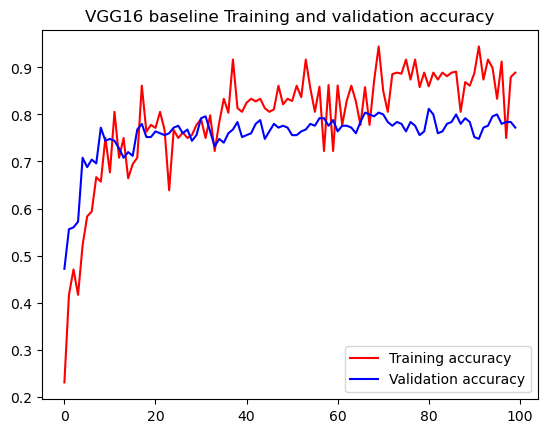

<Figure size 640x480 with 0 Axes>

In [59]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('VGG16 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/VGG16_Baseline_Accuracy.png')

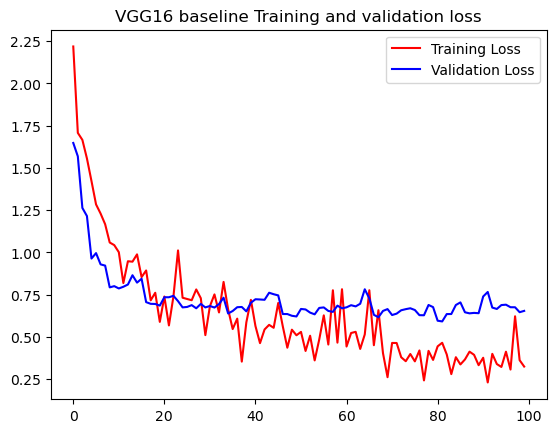

In [60]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('VGG16 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/VGG16_Baseline_Loss.png')

### Section 4 : Baseline CNN Modelling (ResNet50) on Original Data

In [69]:
# Using ResNet50 model with pretrained weights
conv_base_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_res = models.Sequential()
model_res.add(conv_base_res)
model_res.add(layers.Flatten())
model_res.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778232857.556734    2300 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [70]:
# for layer in conv_base_res.layers:
#     layer.trainable = False

In [71]:
model_res.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
filepath = './results_and_models/baseline_resnet_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

#### ResNet50 Model Fit

In [73]:
# Train the model
history = model_res.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 32,
    validation_data=validation_generator,
    validation_steps=8,
    callbacks = [checkpoint],
    verbose=2
    )

Epoch 1/100


I0000 00:00:1778232905.580191    4657 service.cc:148] XLA service 0x7f87e8002950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778232905.580230    4657 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-08 09:35:06.775132: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778232910.107977    4657 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-08 09:35:12.411980: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[36,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activati


Epoch 1: val_accuracy improved from None to 0.08400, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.01-4.45.keras


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 - 96s - 3s/step - accuracy: 0.5857 - loss: 1.6830 - val_accuracy: 0.0840 - val_loss: 4.4451
Epoch 2/100

Epoch 2: val_accuracy did not improve from 0.08400
32/32 - 1s - 30ms/step - accuracy: 0.7500 - loss: 0.6051 - val_accuracy: 0.0840 - val_loss: 4.5314
Epoch 3/100

Epoch 3: val_accuracy did not improve from 0.08400
32/32 - 13s - 394ms/step - accuracy: 0.8848 - loss: 0.4303 - val_accuracy: 0.0840 - val_loss: 3.2681
Epoch 4/100

Epoch 4: val_accuracy improved from 0.08400 to 0.08800, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.04-3.23.keras
32/32 - 2s - 68ms/step - accuracy: 0.8889 - loss: 0.4723 - val_accuracy: 0.0880 - val_loss: 3.2266
Epoch 5/100

Epoch 5: val_accuracy improved from 0.08800 to 0.09200, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.05-5.72.keras
32/32 - 14s - 431ms/step - accuracy: 0.8955 - loss: 0.4118 - val_accuracy: 0.0920 - val_loss: 5.7239
Epoch 6/100

Epoch 6: val_accuracy did not improve f

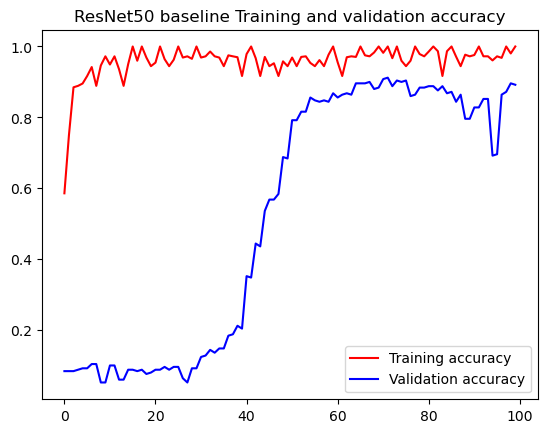

<Figure size 640x480 with 0 Axes>

In [77]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('ResNet50 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/ResNet50_Baseline_Accuracy.png')

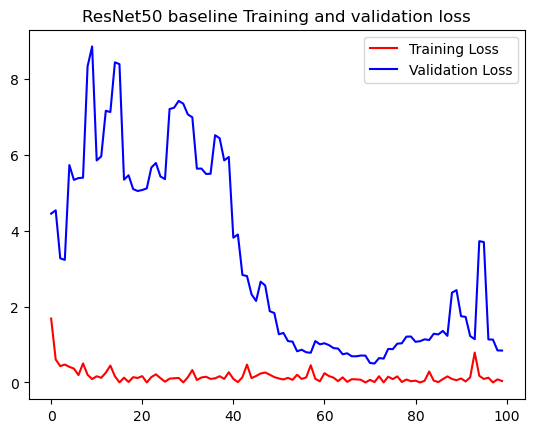

In [78]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('ResNet50 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/ResNet50_Baseline_Loss.png')